In [1]:
import getdist.plots as gdplt
import cobaya
from cobaya.yaml import yaml_load_file
from cobaya.run import run
import numpy as np
from scipy import stats

In [2]:
import os
# access DESI data


In [4]:
def loglike_DESI(Omega_m):
    path_data = r"C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2"

    list_filename = os.listdir(path_data)
    list_mean = []
    for f in list_filename:
        if f.endswith("mean.txt"):
            list_mean.append(f)
    mask = [0, 0, 1, 1, 1, 1, 1, 1]

    list_mean_filt = []
    for i in range(len(mask)):
        if mask[i] == 1:
            list_mean_filt.append(list_mean[i])

    redshifts = []
    DMoverRs = []
    DHoverRs = []
    cov = []

    for f in list_mean_filt:
        data = np.loadtxt(path_data +"\\"+ f, dtype=str)
        z = data[0,0].astype(float)
        if data[0, 2] == "DM_over_rs":
            DMoverRs.append(data[0, 1].astype(float))
            DHoverRs.append(data[1, 1].astype(float))
        else:
            DHoverRs.append(data[0, 1].astype(float))
            DMoverRs.append(data[1, 1].astype(float))
        redshifts.append(z)

    # order redshifts and corresponding DM/rs and DH/rs
    redshifts = np.array(redshifts)
    DMoverRs = np.array(DMoverRs)
    DHoverRs = np.array(DHoverRs)
    idx = np.argsort(redshifts)
    redshifts = redshifts[idx]
    DMoverRs = DMoverRs[idx]
    DHoverRs = DHoverRs[idx]

    list_mean_filt = np.array(list_mean_filt)
    list_mean_filt = list_mean_filt[idx]

    for f in list_mean_filt:
        cov_file = f.replace("mean", "cov")
        data = np.loadtxt(path_data +"\\"+ cov_file)
        cov.append(data)

    #---------------------------------------------------------------------
    # compute model predictions for DM/rs and DH/rs at the given redshifts
    DMoverRs_model = []
    DHoverRs_model = []

    def expansion_rate(z, Omega_m, Omega_Lambda, w0=-1.0, wa=0): # by default lambdaCDM
        """    
        Parameters:
        z Redshift
        Omega_m Matter density parameter
        Omega_Lambda DE density parameter
        w0 constant equation of state parameter for DE
        wa varying equation of state parameter for DE

        Returns: E(z) = H(z)/H0
        """
        Omega_DE = Omega_Lambda * (1 + z)**(3 * (1 + w0 + wa)) * np.exp(-3 * wa * z / (1 + z))

        Omega_total = Omega_m * (1 + z)**3 + Omega_DE

        E_z = np.sqrt(Omega_total)
        return E_z

    def trans_comoving_dist_array(z, par):
        """
        Returns: Transverse comoving distance D_M(z) in units of h^-1 Mpc
        """
        c = 299792.458  # km/s
        from scipy.integrate import quad

        Omega_m = par
        Omega_Lambda = 1 - Omega_m  # Assuming a flat universe

        def integrand(z_prime):
            return 1 / expansion_rate(z_prime, Omega_m, Omega_Lambda)

        integral1, _ = quad(integrand, 0, z[0])
        integrals = []
        for i in range(len(z)):
            part_int = quad(integrand, z[i-1], z[i])[0] if i > 0 else integral1
            integrals.append(part_int + (integrals[i-1] if i > 0 else 0))
        return [c/100 * el for el in integrals]

    def Hubble_dist(z, par):# Omega_m, Omega_Lambda, w0=-1.0, wa=0):
        """
        Returns: Hubble distance D_H(z) in units of h^-1 Mpc
        """
        Omega_m = par
        Omega_Lambda = 1 - Omega_m  # Assuming a flat universe
        c = 299792.458  # km/s
        return c/100 / expansion_rate(z, Omega_m, Omega_Lambda)
    

    # H0 = 70
    # Ob = 0.049
    # h = H0/100
    # params = camb.CAMBparams()
    # params.set_cosmology(H0=70, ombh2=(Ob*h**2), omch2=((Omega_m-Ob)*h**2), mnu=0.06, omk=0, tau=0.06)
    # params.WantTransfer = False
    # params.WantTensors = False
    # params.WantDerivedParameters  = False
    # params.Want_cl_2D_array = False
    # params.Want_CMB_lensing = False
    # params.DoLensing = False
    # params.want_zdrag  = False
    # params.want_zstar  = False

    # results = camb.get_results(params)

    # rs = results.sound_horizon(1060) * h
    rs = 100

    for z in redshifts:
        DHoverRs_model.append(Hubble_dist(z, Omega_m))
        
    DMoverRs_model = trans_comoving_dist_array(redshifts, Omega_m)
    DMoverRs_model = np.array(DMoverRs_model)
    DMoverRs_model = [dm / rs for dm in DMoverRs_model]
    DHoverRs_model = np.array(DHoverRs_model)
    DHoverRs_model = [dh / rs for dh in DHoverRs_model]
    
    # compute chi-squared
    chi2 = 0
    for i in range(len(redshifts)):
        data_vector = np.array([DMoverRs[i], DHoverRs[i]])
        model_vector = np.array([DMoverRs_model[i], DHoverRs_model[i]])
        cov_matrix = cov[i]
        chi2 += (data_vector - model_vector).T @ np.linalg.inv(cov_matrix) @ (data_vector - model_vector)
    
    return -0.5 * chi2


In [2]:
import cobaya.theories.cosmo.boltzmannbase as bb
theory = bb.initialize()
# must_provide()

AttributeError: module 'cobaya.theories.cosmo.boltzmannbase' has no attribute 'initialize'

In [ ]:
def bao_like(_self=None):
    
    theory = _self.provider
    # 1. get theory predictions (we'll learn how next)
    z = 1.484
    DH_data = 130
    DH_unc = 5
    DM_data = 3000
    DM_unc = 100
    H = theory.get_Hubble(z)
    DH = 299792.458 / H
    DM = theory.get_comoving_radial_distance(z)
    # rs = theory.rs_drag

    # 3. compare with data
    chi2 = ((DH - DH_data) / DH_unc)**2 + ((DM - DM_data) / DM_unc)**2

    return -0.5 * chi2

In [ ]:
info = {"likelihood": {"BAO_test": bao_like}}


In [ ]:
info = {"likelihood": {"DESI_BAO": loglike_DESI}, {"requires": {}}}
info["params"] = {
    "Omega_m": {"prior": {"min": 0.01, "max": 0.99}, "ref": 0.4, "proposal": 0.01, "latex": r"\Omega_m"}}

info["sampler"] = {"mcmc": {"Rminus1_stop": 0.01, "max_tries": 1000}} # diagonalized Gelman-Rubin param

In [ ]:
updated_info, sampler = run(info)

In [2]:
def gauss_ring_logp(x, y, mean_radius=1, std=0.01):
    """
    Defines a gaussian ring likelihood in cartesian coordinates,
    around some ``mean_radius`` and with some ``std``.
    """
    return stats.norm.logpdf(np.sqrt(x**2 + y**2), loc=mean_radius, scale=std)

def x_eq_y_band(x, y, mean=0, std=0.3):
    return stats.norm.logpdf(x - y, loc=mean, scale=std)

def get_r(x, y):
    return np.sqrt(x ** 2 + y ** 2)


def get_theta(x, y):
    return np.arctan(y / x)

In [3]:
info = {"likelihood": {"ring": gauss_ring_logp}}

info["params"] = {
    "x": {"prior": {"min": 0, "max": 2}, "ref": 1.5, "proposal": 0.1},
    "y": {"prior": {"min": 0, "max": 2}, "ref": 1.5, "proposal": 0.1}}

# info["prior"] = {"x_eq_y_band": x_eq_y_band}

info["params"]["r"] = {"derived": get_r}
info["params"]["theta"] = {"derived": get_theta,
                           "latex": r"\theta", "min": 0, "max": np.pi/2}

In [4]:
info["sampler"] = {"mcmc": {"Rminus1_stop": 0.01, "max_tries": 1000}} # diagonalized Gelman-Rubin param

In [5]:
updated_info, sampler = run(info)

[ring] Initialized external likelihood.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: x:1.5, y:1.5
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {ring: 5750.0}
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling!
[mcmc] Progress @ 2026-03-19 12:29:11 : 1 steps taken, and 0 accepted.
[mcmc] Learn + convergence test @ 80 samples accepted.
[mcmc]  - Acceptance rate: 0.088
[mcmc]  - Convergence of means: R-1 = 2.311807 after 64 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 160 samples accepted.
[mcmc]  - Acceptance rate: 0.087
[mcmc]  - Convergence of means: R-1 = 0.455095 after 128 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 240 samples accepted.
[mcmc]  - Acceptance rate: 0.064

In [6]:
gd_sample = sampler.products(to_getdist=True, skip_samples=0.3)["sample"]

[root] *WARNING* outlier fraction 0.0762987012987013 


Mean: [0.68171028 0.6947681 ]
Covariance matrix:
 [[ 0.027165   -0.02494861]
 [-0.02494861  0.02550597]]


(2, 1)

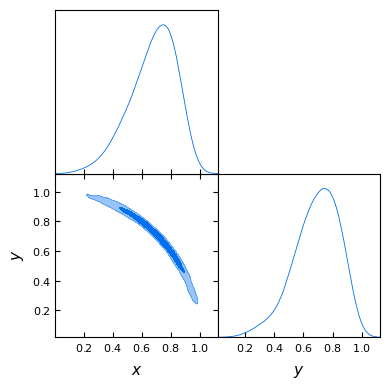

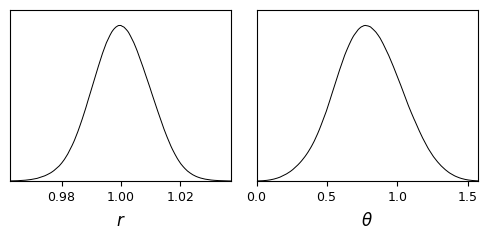

In [ ]:
# analysis and plots
mean = gd_sample.getMeans()[:2]
covmat = gd_sample.getCovMat().matrix[:2, :2]
print("Mean:", mean)
print("Covariance matrix:\n", covmat)
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, ["x", "y"], filled=True)

gdplot = gdplt.get_subplot_plotter(width_inch=5)
gdplot.plots_1d(gd_sample, ["r", "theta"], nx=2)

In [7]:
from mpi4py import MPI

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

from cobaya import run
from cobaya.log import LoggedError

success = False
try:
    upd_info, mcmc = run(info)
    success = True
except LoggedError as err:
    pass

# Did it work? (e.g. did not get stuck)
success = all(comm.allgather(success))

if not success and rank == 0:
    print("Sampling failed!")

[ring] Initialized external likelihood.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: x:1.5, y:1.5
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {ring: 3920.0}
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling!
[mcmc] Progress @ 2026-03-19 12:35:24 : 1 steps taken, and 0 accepted.
[mcmc] Learn + convergence test @ 80 samples accepted.
[mcmc]  - Acceptance rate: 0.098
[mcmc]  - Convergence of means: R-1 = 2.294403 after 64 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 160 samples accepted.
[mcmc]  - Acceptance rate: 0.097
[mcmc]  - Convergence of means: R-1 = 8.585510 after 128 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 240 samples accepted.
[mcmc]  - Acceptance rate: 0.089

In [32]:
fiducial_params = {
    "ombh2": 0.022,
    "omch2": 0.12,
    "H0": 68,
    "tau": 0.07,
    "As": 2.2e-9,
    "ns": 0.96,
    "mnu": 0.06,
    "nnu": 3.046,
}

l_max = 1000

packages_path = r"C:\EPFL\MA4\code\COBAYA_packages"

info_fiducial = {
    "params": fiducial_params,
    "likelihood": {"one": None},
    "theory": {"camb": {"extra_args": {"num_massive_neutrinos": 1}}},
    "packages_path": packages_path,
}

from cobaya.model import get_model

model_fiducial = get_model(info_fiducial)

# Declare our desired theory product
# (there is no cosmological likelihood doing it for us)
model_fiducial.add_requirements({"Hubble": {"z": 1.484}, "comoving_radial_distance": {"z": 1.484}})


model_fiducial.logposterior({})
H = model_fiducial.provider.get_Hubble(z=1.484)
DM = model_fiducial.provider.get_comoving_radial_distance(z=1.484)
print(299792.458 / H)
# Our fiducial power spectrum
print("Hubble  at z=1.484:", H)
print("Comoving radial distance at z=1.484:", DM)

[camb] `camb` module loaded successfully from C:\Users\adrie\anaconda3\envs\cobaya\Lib\site-packages\camb
[model] *WARNING* Theories {camb, camb.transfers} do not appear to be actually used for anything
[1893.25278282]
Hubble  at z=1.484: [158.34782377]
Comoving radial distance at z=1.484: [4433.15486883]


In [134]:
def bao_like(_self=None):
    
    theory = _self.provider
    # model
    zs = 1060 # to change later
    camb_data = theory.get_CAMBdata()
    rs = camb_data.sound_horizon(zs)
    
    H = theory.get_Hubble(redshifts)
    DH_rs_model = [299792.458 / h / rs for h in H]
    DM = theory.get_comoving_radial_distance(redshifts)
    DM_rs_model = [dm / rs for dm in DM]
    
    # chi2 computation
    chi2 = 0
    for i in range(len(redshifts)):
        data_vector = np.array([DMoverRs[i], DHoverRs[i]])
        model_vector = np.array([DM_rs_model[i], DH_rs_model[i]])
        cov_matrix = cov[i]
        chi2 += (data_vector - model_vector).T @ np.linalg.inv(cov_matrix) @ (data_vector - model_vector)
        # simpler version
        # chi2 += (data_vector - model_vector).T @ (data_vector - model_vector)
    return -0.5 * chi2

In [121]:
import os
path_data = r"C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2"

list_filename = os.listdir(path_data)
list_mean = []
for f in list_filename:
    if f.endswith("mean.txt"):
        list_mean.append(f)
mask = [0, 0, 1, 1, 1, 1, 1, 1]

list_mean_filt = []
for i in range(len(mask)):
    if mask[i] == 1:
        list_mean_filt.append(list_mean[i])

redshifts = []
DMoverRs = []
DHoverRs = []
cov = []

for f in list_mean_filt:
    data = np.loadtxt(path_data +"\\"+ f, dtype=str)
    z = data[0,0].astype(float)
    if data[0, 2] == "DM_over_rs":
        DMoverRs.append(data[0, 1].astype(float))
        DHoverRs.append(data[1, 1].astype(float))
    else:
        DHoverRs.append(data[0, 1].astype(float))
        DMoverRs.append(data[1, 1].astype(float))
    redshifts.append(z)

# order redshifts and corresponding DM/rs and DH/rs
redshifts = np.array(redshifts)
DMoverRs = np.array(DMoverRs)
DHoverRs = np.array(DHoverRs)
idx = np.argsort(redshifts)
redshifts = redshifts[idx]
DMoverRs = DMoverRs[idx]
DHoverRs = DHoverRs[idx]

list_mean_filt = np.array(list_mean_filt)
list_mean_filt = list_mean_filt[idx]

for f in list_mean_filt:
    cov_file = f.replace("mean", "cov")
    data = np.loadtxt(path_data +"\\"+ cov_file)
    cov.append(data)

C:\Users\adrie\AppData\Local\Temp\ipykernel_42820\746886358.py:22: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt(path_data +"\\"+ f, dtype=str)


In [ ]:
info = {
    "params": {
        # Fixed
        "ombh2": 0.022,
        # "omch2": 0.12,
        # "H0": 68,
        "tau": 0.07,
        "mnu": 0.06,
        "nnu": 3.046,
        # Sampled
        "H0": {"prior": {"min": 50, "max": 80}, "ref": 70, "proposal": 1.0, "latex": "H_0"},
        # "rs": {"prior": {"min": 50, "max": 150}, "ref": 100, "proposal": 1.0, "latex": "r_s"},
        "omch2": {"prior": {"min": 0.01, "max": 0.25}, "ref": 0.12, "proposal": 0.001, "latex": r"\omega_{cdm}"},
        # "ombh2": {"prior": {"min": 0.01, "max": 0.03}, "ref": 0.022, "proposal": 0.001, "latex": r"\omega_{b}"}
        },
    "likelihood": {
        "test_like": {
            "external": bao_like,
            # Declare required quantities!
            "requires": {"Hubble": {"z": redshifts}, 
                         "comoving_radial_distance": {"z": redshifts},
                        #  "sound_horizon": None
                         "CAMBdata": None
                         },
            "derived": {"Omega_m": lambda H0, ombh2, omch2: (ombh2 + omch2) / (H0/100)**2}
                    }
    },
    "theory": {"camb": {"stop_at_error": True}},
    "packages_path": packages_path,
}

info["sampler"] = {"mcmc": {"Rminus1_stop": 0.2, "max_tries": 1000}} # diagonalized Gelman-Rubin param

In [142]:
# model = get_model(info)
# model.logposterior({})

# theory = model.provider
# H = theory.get_Hubble(redshifts)
# zs = 1060 # to change later
# camb_data = theory.get_CAMBdata()
# rs = camb_data.sound_horizon(zs)
# print("Sound horizon at z=1060:", rs)
# print("Hubble:", H)


In [140]:
updated_info, sampler = run(info)

[camb] `camb` module loaded successfully from C:\Users\adrie\anaconda3\envs\cobaya\Lib\site-packages\camb
[test_like] Initialized external likelihood.
[mcmc] Getting initial point... (this may take a few seconds)


[mcmc] Initial point: H0:70, omch2:0.12
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {test_like: 2230.0, camb.transfers: 77.9, camb: 718.0}
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling!
[mcmc] Progress @ 2026-03-20 15:01:49 : 1 steps taken, and 0 accepted.
[mcmc] Learn + convergence test @ 80 samples accepted.
[mcmc]  - Acceptance rate: 0.162
[mcmc]  - Convergence of means: R-1 = 1.363196 after 64 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 160 samples accepted.
[mcmc]  - Acceptance rate: 0.247
[mcmc]  - Convergence of means: R-1 = 0.182551 after 128 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 240 samples accepted.
[mcmc]  - Acceptance rate: 0.278
[mcmc]  - Convergence of means: R-1 = 0.130821 after 192

[root] *WARNING* outlier fraction 0.10416666666666667 
Mean: [68.23425525  0.11180116]
Covariance matrix:
 [[6.83438242e-02 9.39678719e-05]
 [9.39678719e-05 2.21052361e-05]]


(2, 1)

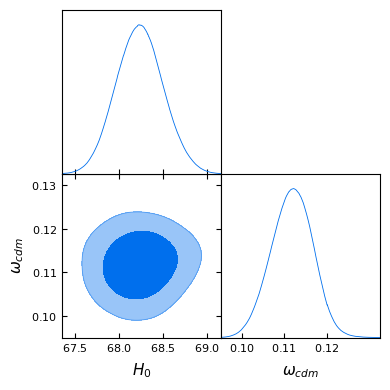

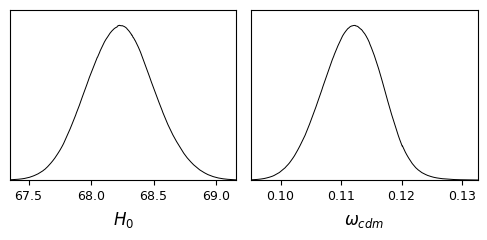

In [ ]:
# analysis and plots

gd_sample = sampler.products(to_getdist=True, skip_samples=0.3)["sample"]
mean = gd_sample.getMeans()[:2]
covmat = gd_sample.getCovMat().matrix[:2, :2]
print("Mean:", mean)
print("Covariance matrix:\n", covmat)
gdplot = gdplt.get_subplot_plotter()

gdplot.triangle_plot(gd_sample, ["H0", "omch2"], filled=True)
# gdplot.triangle_plot(gd_sample, ["H0", "omch2", "ombh2"], filled=True)
# gdplot.triangle_plot(gd_sample, ["H0"], filled=True)

gdplot = gdplt.get_subplot_plotter(width_inch=5)
gdplot.plots_1d(gd_sample, ["H0", "omch2"], nx=2)
# gdplot.plots_1d(gd_sample, ["H0", "omch2", "ombh2"], nx=2)
# gdplot.plots_1d(gd_sample, ["H0"], nx=2)

# test $\Lambda \text{CDM}$ using Cobaya samples on DESI DR2 data

In [82]:
path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM"
file2 = path + r"\base_LCDM_Om_hrdrag.1.txt"
file3 = path + r"\Om_hrdrag_test_ref.1.txt"
H0_ = [20, 30, 40, 50, 60, 70, 80, 90, 100]
filename = path + r"\Om_hrdrag_H0=90"
files_H0 = [path + r"\Om_hrdrag_H0=" + str(H) + r".1.txt" for H in H0_]

sampler = np.loadtxt(files_H0[-1])

names = [r"H_0", r"\Omega_m"] # --> 2 et 4
names = [r"hr_\mathrm{drag}", r"\Omega_m"] # --> 2 et 6

n = 200
# samples = [sampler[:n, 2], sampler[:n, 6]]
#last n
samples = [sampler[-n:, 2], sampler[-n:, 6]]
# samples = [sampler[:, 2], sampler[:, 6]]
# print(np.array(samples))
samples = np.array(samples)
samples = samples.T

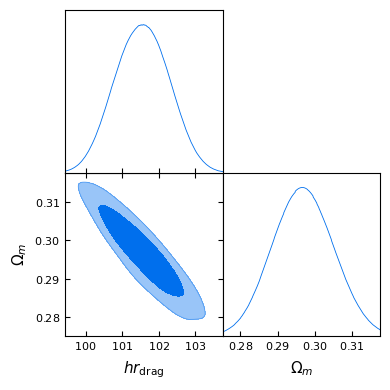

In [83]:
from getdist import MCSamples
gd_sample = MCSamples(samples=samples, names=names, labels=names)
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

# test $w_0w_a\text{CDM}$ using Cobaya samples on DESI DR2 data

In [ ]:
path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa"
file1= path + r"\test1_H0=70.1.txt"
# file3 = path + r"\Om_hrdrag_test_ref.1.txt"
# H0_ = [20, 30, 40, 50, 60, 70, 80, 90, 100]
# filename = path + r"\Om_hrdrag_H0=90"
# files_H0 = [path + r"\Om_hrdrag_H0=" + str(H) + r".1.txt" for H in H0_]

sampler = np.loadtxt(file1)
names = [r"hr_\mathrm{drag}", "w_0", "w_a", r"\Omega_m"]
samples = [sampler[:, 2], sampler[:, 4], sampler[:, 5], sampler[:, 8]]

nsamples = len(samples[0])
print("There are {} samples".format(nsamples))
n = int(4*nsamples/5)
print("Taking the last {} samples".format(n))
samples = [samples[i][-n:] for i in range(len(samples))]

samples = np.array(samples)
samples = samples.T

There are 8760 samples
Taking the last 7008 samples


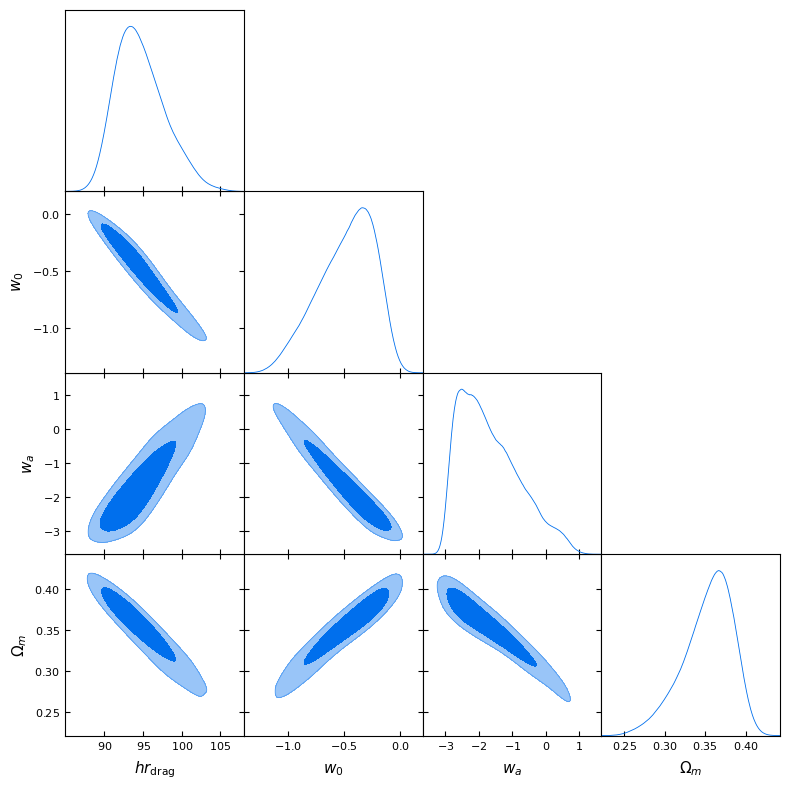

In [100]:
from getdist import MCSamples
gd_sample = MCSamples(samples=samples, names=names, labels=names)
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)